First 5 Rows:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes         78

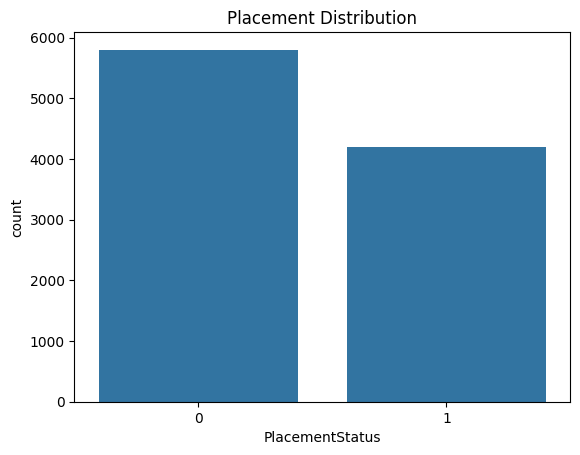

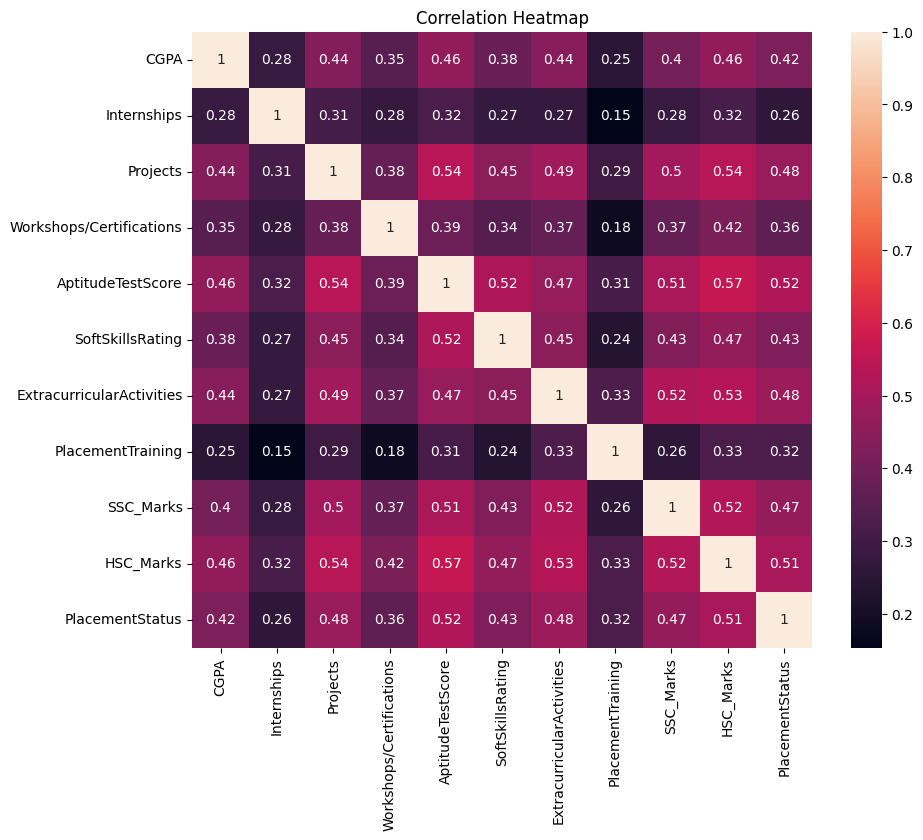

Model Saved Successfully!

SAMPLE STUDENT PREDICTION
Placed


In [1]:
# ==========================================
# STUDENT PLACEMENT PREDICTOR
# ==========================================

# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("placedata v2.0 synthetic.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# 3. DROP STUDENT ID
# ==========================================

df.drop("StudentID", axis=1, inplace=True)

# ==========================================
# 4. CONVERT CATEGORICAL COLUMNS
# ==========================================

df["ExtracurricularActivities"] = df["ExtracurricularActivities"].map({
    "Yes": 1,
    "No": 0
})

df["PlacementTraining"] = df["PlacementTraining"].map({
    "Yes": 1,
    "No": 0
})

df["PlacementStatus"] = df["PlacementStatus"].map({
    "Placed": 1,
    "NotPlaced": 0
})

print("\nData Types After Encoding:")
print(df.dtypes)

# ==========================================
# 5. FEATURES AND TARGET
# ==========================================

X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

# ==========================================
# 6. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 7. LOGISTIC REGRESSION
# ==========================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# ==========================================
# 8. RANDOM FOREST
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# ==========================================
# 9. CONFUSION MATRIX
# ==========================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# ==========================================
# 10. FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

import seaborn as sns
import matplotlib.pyplot as plt

# Placement Distribution
sns.countplot(x="PlacementStatus", data=df)
plt.title("Placement Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

import joblib

joblib.dump(lr_model, "placement_model.pkl")

print("Model Saved Successfully!")

# ==========================================
# 11. SAMPLE PREDICTION
# ==========================================

sample_student = pd.DataFrame({
    "CGPA": [8.5],
    "Internships": [2],
    "Projects": [4],
    "Workshops/Certifications": [3],
    "AptitudeTestScore": [85],
    "SoftSkillsRating": [8.0],
    "ExtracurricularActivities": [1],
    "PlacementTraining": [1],
    "SSC_Marks": [88],
    "HSC_Marks": [82]
})

prediction = rf_model.predict(sample_student)

print("\n==============================")
print("SAMPLE STUDENT PREDICTION")
print("==============================")

if prediction[0] == 1:
    print("Placed")
else:
    print("Not Placed")

In [4]:
import joblib

joblib.dump(lr_model, "placement_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [5]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
9                  HSC_Marks    0.211044
4          AptitudeTestScore    0.178484
8                  SSC_Marks    0.133290
0                       CGPA    0.120347
5           SoftSkillsRating    0.094343
2                   Projects    0.073408
6  ExtracurricularActivities    0.072964
3   Workshops/Certifications    0.058424
1                Internships    0.033324
7          PlacementTraining    0.024372


In [6]:
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

# Random Forest
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.7945
Random Forest Accuracy: 0.7815
